In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ["MPLCONFIGDIR"] = f"/tmp/{os.environ['USER']}_matplotlib_cache"

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [9]:
import json
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
from pathlib import Path
import sys
import pandas as pd

import cogwheel.likelihood
import cogwheel.data
import cogwheel.gw_plotting
import cogwheel.plotting
from cogwheel.plotting import latex_val_err
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors
import gwosc
import gwpy.table
from pesummary.io import read

sys.path.insert(0, '../code')
import helpers

In [4]:
# load samples from event posterior(s)
prior_class = 'IntrinsicLVCPrior'

# where we've saved the posteriors and samples
resdir = f'../data/pe_runs_lensing/{prior_class}'

# list of event directories
event_dir_list = glob.glob(f'{resdir}/GW*')
all_eventnames = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(all_eventnames)} events in {resdir}")

found 58 events in ../data/pe_runs_lensing/IntrinsicLVCPrior


In [5]:
# select a subset of all the events in the catalog, for which to make .npz files
catalog = 'GWTC-5.0'
selection = 'network_matched_filter_snr > 13'
event_tables = gwpy.table.EventTable.fetch_open_data(catalog, selection=selection)
eventname_list = []
for name in all_eventnames:
    if name in ''.join(event_tables['name']):
        eventname_list.append(name)
print(f"{len(eventname_list)} of these events are from {catalog} with {selection}")

33 of these events are from GWTC-5.0 with network_matched_filter_snr > 13


In [10]:
# compute Bayes factors and make corner plot
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))
n_resamples = 1000

save_dir = f'../data/plots/pe_corner/{catalog}'
save_fns = []
os.makedirs(save_dir, exist_ok=True)
lnBayes = {}
for eventname in eventname_list:
    event_path = os.path.join(resdir, eventname)
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(event_path, eventname)
    except FileNotFoundError:
        print(f"no samples found for {eventname}. continuing")
        continue

    save_fn = os.path.join(save_dir, f'{eventname}.pdf')
    if os.path.exists(save_fn):
        print(f"plot already exists for {eventname}. continuing")
        continue
    
    # Bayes factor
    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    try:
        lnBayes[eventname] = np.load(lnBayes_fn)
    except FileNotFoundError:
        bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
        # log these
        lnBayes_factors = np.log(bayes_factors)
        # get the median and standard deviation
        lnBayes[eventname] = (np.median(lnBayes_factors), np.std(lnBayes_factors))
        np.save(lnBayes_fn, lnBayes[eventname])

    samples['cosiota'] = np.cos(samples['iota'])
    pars_to_plot = [
        'mchirp', 'q', 'cosiota', 'psi', 'phi_ref', 'chieff', 'd_luminosity', 'ra', 'dec', 'p_lensed'
    ]
    try:
        cp = cogwheel.gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)
        cp.plot()
    except ValueError as e:  # if there's an issue plotting p_lensed, probably
        plt.close(cp.fig)
        print(f"ValueError: {e}. removing p_lensed and attempting to plot again...")
        pars_to_plot.remove('p_lensed')
        cp = cogwheel.gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)
        cp.plot()
    lnB = lnBayes[eventname]
    lnB_str = 'NaN' if np.isnan(lnB[0]) else f'{lnB[0]:.3f}'r'$\pm$'f'{lnB[1]:.3f}'
    title_str = f'{eventname}: 'r'$\ln\mathcal B =$'+lnB_str
    cp.fig.suptitle(title_str, y=0.97)
    cp.fig.savefig(save_fn, bbox_inches='tight', pad_inches=0.2)
    plt.close(cp.fig)
    save_fns.append(save_fn)

loaded posterior samples for GW241011_233834 run 0
loaded posterior samples for GW240923_204006 run 0
loaded posterior samples for GW240915_001357 run 0
loaded posterior samples for GW250119_025138 run 0
loaded posterior samples for GW241111_111552 run 0
loaded posterior samples for GW240925_005809 run 0
loaded posterior samples for GW241225_082815 run 0
loaded posterior samples for GW250109_010541 run 0
loaded posterior samples for GW241129_021832 run 0
loaded posterior samples for GW250118_170523 run 0
loaded posterior samples for GW240919_061559 run 0
loaded posterior samples for GW240511_031507 run 0
loaded posterior samples for GW241225_042553 run 0
loaded posterior samples for GW240413_022019 run 0
loaded posterior samples for GW240930_035959 run 0
loaded posterior samples for GW241130_034908 run 0
loaded posterior samples for GW240705_053215 run 0
loaded posterior samples for GW250114_082203 run 0
loaded posterior samples for GW240920_124024 run 0
loaded posterior samples for GW

In [11]:
# combine pdfs
pdf_paths_str = ' '.join(save_fns)
bigpdf_path = os.path.join(save_dir, f'{catalog}_corners.pdf')
!gs -dBATCH -dNOPAUSE -q -sDEVICE=pdfwrite -dPDFSETTINGS=/prepress -sOutputFile={bigpdf_path} {pdf_paths_str}

In [12]:
# split
c1, c2 = 'royalblue', 'mediumseagreen'
plotstyles = [
        cogwheel.plotting.PlotStyle(color_2d=c1, contour_kwargs=dict(alpha=0.7), kwargs_1d=dict(color=c1, alpha=0.7), tail_probability=1e-3),
        cogwheel.plotting.PlotStyle(color_2d=c2, contour_kwargs=dict(alpha=0.7), kwargs_1d=dict(color=c2, alpha=0.7), tail_probability=1e-3)
]
save_fns = []
for eventname in eventname_list:
    event_path = os.path.join(resdir, eventname)
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(event_path, eventname)
    except FileNotFoundError:
        print(f"no samples found for {eventname}. continuing")
        continue

    save_fn = os.path.join(save_dir, f'{eventname}_split.pdf')
    if os.path.exists(save_fn):
        print(f"plot already exists for {eventname}. continuing")
        continue
    samples['cosiota'] = np.cos(samples['iota'])
    lensed_idx = samples['lensed']
    pars_to_plot = [
        'mchirp', 'q', 'cosiota', 'psi', 'phi_ref', 'chieff', 'd_luminosity', 'ra', 'dec', 'p_lensed'
    ]
    try:
        cp = cogwheel.gw_plotting.MultiCornerPlot({'lensed' : samples[lensed_idx], 'unlensed' : samples[~lensed_idx]},
                                            params=pars_to_plot, plotstyles=plotstyles)
        cp.plot()
    except ValueError as e:  # if there's an issue plotting p_lensed, probably
        plt.close(cp.corner_plots[0].fig)
        print(f"ValueError: {e}. removing p_lensed and attempting to plot again...")
        pars_to_plot.remove('p_lensed')
        cp = cogwheel.gw_plotting.MultiCornerPlot({'lensed' : samples[lensed_idx], 'unlensed' : samples[~lensed_idx]},
                                            params=pars_to_plot, plotstyles=plotstyles)
        try:
            cp.plot()
        except Exception as e:
            plt.close(cp.corner_plots[0].fig)
            print(f"exception! {e} continuing to next event.")
            continue
    except Exception as e:
        plt.close(cp.corner_plots[0].fig)
        print(f"exception! {e} continuing to next event.")
        continue

    lnB = lnBayes[eventname]
    lnB_str = 'NaN' if np.isnan(lnB[0]) else f'{lnB[0]:.3f}'r'$\pm$'f'{lnB[1]:.3f}'
    title_str = f'{eventname}: 'r'$\ln\mathcal B =$'+lnB_str
    fig = cp.corner_plots[0].fig
    fig.suptitle(title_str, y=0.97)
    fig.savefig(save_fn, bbox_inches='tight', pad_inches=0.2)
    plt.close(fig)
    save_fns.append(save_fn)

loaded posterior samples for GW241011_233834 run 0
loaded posterior samples for GW240923_204006 run 0
loaded posterior samples for GW240915_001357 run 0
loaded posterior samples for GW250119_025138 run 0
loaded posterior samples for GW241111_111552 run 0
loaded posterior samples for GW240925_005809 run 0
loaded posterior samples for GW241225_082815 run 0
loaded posterior samples for GW250109_010541 run 0
loaded posterior samples for GW241129_021832 run 0
loaded posterior samples for GW250118_170523 run 0
loaded posterior samples for GW240919_061559 run 0
loaded posterior samples for GW240511_031507 run 0
loaded posterior samples for GW241225_042553 run 0
loaded posterior samples for GW240413_022019 run 0
loaded posterior samples for GW240930_035959 run 0
loaded posterior samples for GW241130_034908 run 0
loaded posterior samples for GW240705_053215 run 0
loaded posterior samples for GW250114_082203 run 0
loaded posterior samples for GW240920_124024 run 0
loaded posterior samples for GW

In [13]:
# combine pdfs
pdf_paths_str = ' '.join(save_fns)
bigpdf_path = os.path.join(save_dir, f'{catalog}_corners_split.pdf')
!gs -dBATCH -dNOPAUSE -q -sDEVICE=pdfwrite -dPDFSETTINGS=/prepress -sOutputFile={bigpdf_path} {pdf_paths_str}

### the two events from Javier: GW190412 and GW190814

In [18]:
eventname_list_subset = ['GW190412', 'GW190814']
event_dir_subset = np.array([glob.glob(f'{resdir}/{x}*') for x in eventname_list_subset]).flatten()

loaded posterior samples for GW190412 run 0
couldn't find any LVK samples for GW190412 (in GWTC-4.0 or GWTC-2.1)
GW190412:	2.8358 +- 0.0226
loaded posterior samples for GW190814 run 0
couldn't find any LVK samples for GW190814 (in GWTC-4.0 or GWTC-2.1)
GW190814:	0.5808 +- 0.0042


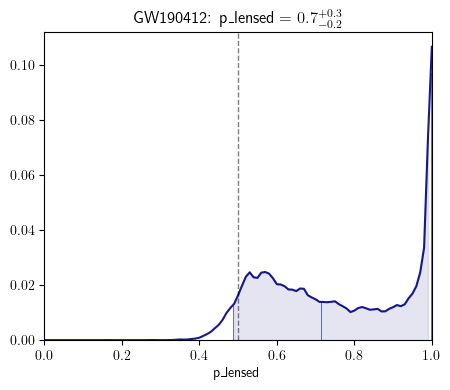

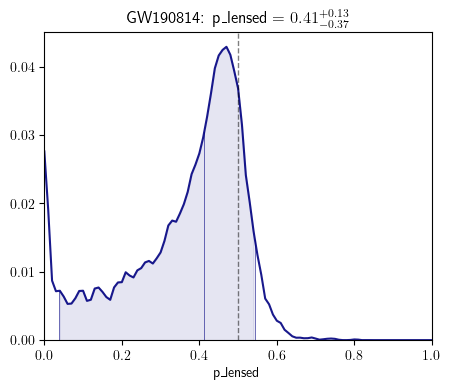

In [19]:
for (eventname, event_path) in zip(eventname_list_subset, event_dir_subset):
    samples = load_posterior_samples(eventname, event_path)
    if samples is None:
        continue
    samples_lvk = load_lvk_samples(eventname)

    # plot the p_lensed distribution
    plot_p_lensed(samples, eventname=eventname)

    # and compute Bayes factor and uncertainty
    bayes_factors_ = bootstrap_bayes_factors(samples, n_resamples)
    print(f"{eventname}:\t{np.median(bayes_factors_):.4f} +- {np.std(bayes_factors_):.4f}")

#### what if we multiply the GW230814_230901 waveform by $i$? do we get a symmetric `p_lensed` distribution?

In [11]:
eventname = 'GW230814_230901'

# load the results for the original event data to compare
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'
event_path = os.path.join(resdir, eventname)
samples, _ = load_posterior_samples(eventname, event_path)

# and now load the results for the strain data multiplied by i
resdir = '../data/pe_runs_lensing/multiplied_by_i/IntrinsicLVCPrior'
event_path = os.path.join(resdir, eventname)
samples_i, _ = load_posterior_samples(eventname, event_path)

loaded posterior samples for GW230814_230901 run 0
loaded posterior samples for GW230814_230901 run 0


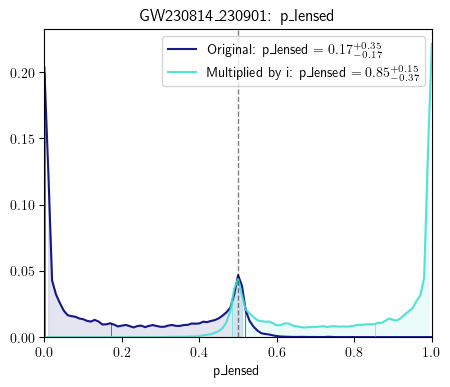

In [12]:
fig, ax = plt.subplots(figsize=(5,4))
cs = ['navy', 'turquoise']
labels = ['Original: p_lensed', 'Multiplied by i: p_lensed']
for i, samples_ in enumerate([samples, samples_i]):
    cp = cogwheel.gw_plotting.CornerPlot(
        samples_, params=['p_lensed'], tail_probability=1e-4
    )
    hist, edges = np.histogram(samples_['p_lensed'], bins=100,
                                weights=samples_['weights'])
    # we want the pdf at edges, not midpoints:
    pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])

    # vlines
    median, *span = cp._get_median_and_central_interval('p_lensed')
    for val in (median, *span):
        ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c=cs[i], alpha=0.8, lw=0.5)
    idx = (edges > span[0]) & (edges < span[1])
    ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color=cs[i], alpha=0.1)
    val_err_str = '${}={}$' + latex_val_err(median, np.subtract(median, span))

    # plot the histogram
    ax.plot(edges, pdf, c=cs[i], alpha=0.9, label=labels[i] + val_err_str)

ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
ax.set_xlabel('p_lensed')
ax.set_xlim(0., 1.)
ax.set_ylim(0., None)
ax.set_title(f"{eventname}: p_lensed")
ax.legend()